<a href="https://colab.research.google.com/github/paddydoc/paddy-doctor-dataset/blob/main/notebooks/cnn_diseases_small_400_split_epoch100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## This notebook demonstrates how to develop an EfficientNet for paddy disease classification using FastAI.

### Sections of this notebook
1. [Setup environment and import datasets](#setup)
2. [Import libraries](#import)
3. [Dataset preparation](#dataset)
3. [Define a deep CNN model](#model)
4. [Model training](#train)
5. [Model testing](#test)
6. [Results](#results)

<a name="setup"></a>
### 1. Setup environment and import datasets


<!-- ####  a. Import dataset

1. Download the Paddy Doctor split balanced dataset file ``paddy-doctor-diseases-small-400-split.zip`` from [this link](https://ieee-dataport.org/documents/paddy-doctor-visual-image-dataset-automated-paddy-disease-classification-and-benchmarking)
2. Create a new folder named ``paddy-doctor`` in your Google Drive's root directory and upload the ``paddy-doctor-diseases-small-400-split.zip`` file there. -->

#### b. Mount Google Drive


In [6]:
# ## mount google drive
# from google.colab import drive
# drive.mount('/content/drive')
# !pwd

In [7]:
# %cd /content/drive/MyDrive/paddy-doctor
# !ls -l

#### c. Extract the datset files

In [8]:
# ## skip this command, if you already have extracted the files
# #!unzip -qq paddy-doctor-diseases-small-splitted.zip
# !unzip -qq paddy-doctor-diseases-small-400-split.zip

##### The ``paddy-doctor`` folder should contains the following directories and files.

In [9]:
# !ls -l
# !find ./train -type f -print | wc -l
# !find ./test -type f -print | wc -l

<a name="import"></a>
### 2. Import python *libraries*


#### Verify the files in the train and test directories

In [10]:
# import glob
# from pathlib import Path

# ## Google Colab (See the above instructions)
# # train_path = '/content/drive/MyDrive/paddy-doctor/train/'
# # test_path  = '/content/drive/MyDrive/paddy-doctor/test/'

# ## Kaggle (create a new dataset with a path "paddy-doctor-diseases-small-400-split" using paddy-doctor-diseases-small-400-split.zip

# train_path = '/kaggle/input/paddy-doctor-disease/split/kaggle/working/paddy-doctor-disease/paddy-doctor-diseases-small_split_400/train/'
# test_path  = '/kaggle/input/paddy-doctor-disease/split/kaggle/working/paddy-doctor-disease/paddy-doctor-diseases-small_split_400/test/'

# print('training set')
# for filepath in glob.glob(train_path + '/*/'):
#     files = glob.glob(filepath + '*')
#     print(f"{len(files)} \t {Path(filepath).name}")

# print('testing set')
# for filepath in glob.glob(test_path + '/*/'):
#     files = glob.glob(filepath + '*')
#     print(f"{len(files)} \t {Path(filepath).name}")

In [20]:
import glob

try: import fastkaggle
except ModuleNotFoundError:
    !pip install -Uq fastkaggle

from fastkaggle import *
from fastai.vision.all import *
set_seed(42)

#/kaggle/input/paddy-doctor-diseases-small-400-split

competition = '/kaggle/input/paddy-doctor-disease/Augmented and split - 26000 augmented images split into train (80) sets'
path = setup_comp(competition, install='fastai "timm>=0.6.2.dev0"')
print(path)

# train images
train_path = path / 'train'
train_files = get_image_files(train_path)

# test images
test_path = path/'test'
test_files = get_image_files(test_path).sorted()

# train labels
train_df = pd.read_csv(path / 'metadata-train.csv')
print(train_df.shape)
train_df.label.value_counts()

/kaggle/input/paddy-doctor-disease/Augmented and split - 26000 augmented images split into train (80) sets
(20800, 4)


label
brown_spot                  1601
downy_mildew                1601
white_stem_borer            1601
blast                       1600
bacterial_leaf_streak       1600
leaf_roller                 1600
tungro                      1600
black_stem_borer            1600
hispa                       1600
yellow_stem_borer           1600
bacterial_leaf_blight       1599
bacterial_panicle_blight    1599
normal                      1599
Name: count, dtype: int64

In [21]:
# dblock = DataBlock(
#     blocks=(ImageBlock, CategoryBlock),
#     get_items=get_image_files,
#     get_y=parent_label,
#     splitter=RandomSplitter(0.2, seed=42),
#     item_tfms=Resize(480, method='squish'),
#     batch_tfms=aug_transforms(size=224, min_scale=0.75)
# )


dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(480, method='squish'),
    batch_tfms=aug_transforms(
        size=224, 
        min_scale=0.75,
        max_rotate=20,      # Increased rotation range
        max_zoom=1.2,       # Increased zoom range
        max_warp=0.2,       # Allow for warping
        p_affine=0.75,      # Probability for affine transforms
        p_lighting=0.75     # Probability for lighting transforms
    ) + [RandomErasing(p=0.5, max_count=1)]  # Randomly erase part of the image for extra robustness
)

dls = dblock.dataloaders(train_path)

In [22]:
dls = ImageDataLoaders.from_folder(
    train_path, 
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(480, method='squish'),
    batch_tfms=aug_transforms(size=224, min_scale=0.75)
)

In [23]:
# pip install timm

In [24]:
# # Use wandb? Resume Training?
# USE_WANDB = config['wandb']

# RESUME_LOGGING = False # Set this to true if you are resuming training from a previous run

# # Create your wandb run
# if wandb.run is not None:
#     print("Closing existing WandB run...")
#     wandb.run.finish()
    
# run_name = '{}_early_submission'.format(config['Name'])

# # If you are resuming an old run
# if USE_WANDB:

#     wandb.login(key="f54d876ebca391d5a1ed3eebb7a43aa7bea9da21") #TODO

#     if RESUME_LOGGING:
#         run = wandb.init(
#             id     = "", ### Insert specific run id here if you want to resume a previous run
#             resume = "must", ### You need this to resume previous runs
#             project = "project-ablations", ### Project should be created in your wandb
#             settings = wandb.Settings(_service_wait=300)
#         )


#     else:
#         run = wandb.init(
#             name    = run_name, ### Wandb creates random run names if you skip this field, we recommend you give useful names
#             reinit  = True, ### Allows reinitalizing runs when you re-run this cell
#             project = "project-ablations", ### Project should be created in your wandb account
#             config  = config ### Wandb Config for your run
#         )

#         ### Save your model architecture as a string with str(model)
#         model_arch  = str(model)
#         ### Save it in a txt file
#         arch_file   = open("model_arch.txt", "w")
#         file_write  = arch_file.write(model_arch)
#         arch_file.close()

#         ### log it in your wandb run with wandb.save()
#         wandb.save('model_arch.txt')

In [25]:
# from timm import create_model
# from fastai.vision.all import vision_learner, error_rate


# def efficientnet_model(**kwargs):
#     # Remove any pretrained argument passed from Fastai
#     kwargs.pop('pretrained', None)
#     return create_model("tf_efficientnet_b0_ns", pretrained=True, **kwargs)

# # learn = vision_learner(dls, efficientnet_model, metrics=error_rate).to_fp16()

# # Create a vision learner with the MixUp callback and convert to FP16.
# learn_eff = vision_learner(
#     dls, efficientnet_model, metrics=error_rate,
#     cbs=[
#         MixUp(),
#         SaveModelCallback(fname='eff_best_model', monitor='error_rate'),
#         WandbCallback(log_model=True)
#     ]
# ).to_fp16()

# # Optionally, run the learning rate finder to choose an optimal learning rate.
# # lr_min, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
# # print(f"Suggested Learning Rates: {lr_min:.2e}, {lr_steep:.2e}")

In [26]:
# %%timeit
# # learn.fine_tune(10, 0.005)

# # Fine-tune the model:
# # - 20 epochs for a longer training period.
# # - Use weight decay (wd) for regularization.
# learn_eff.fine_tune(20, base_lr=0.005, wd=0.01)

In [27]:
import wandb

wandb.login(key="f54d876ebca391d5a1ed3eebb7a43aa7bea9da21")

run = wandb.init(
    project="project-ablations",  # Customize as needed
    name="efficientNet",
    config={
        "epochs": 20,
        "base_lr": 0.005,
        "weight_decay": 0.01,
        "architecture": "EfficientNet"
    },
    reinit=True
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██
eps_0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eps_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
error_rate,█▆▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
lr_0,▄▇▇█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr_1,█▂▂▂▂▂▂▂▃▃▄▄▄▄▄▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁
mom_0,▇▆▃███▇▇▇▇▆▅▄▃▂▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▆▆▇▇▇▇████
mom_1,█▆▅▃█▆▅▅▄▃▂▂▂▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▅▆▆▇▇▇████
raw_loss,█▄▄▃▃▃▃▃▃▃▃▂▂▂▁▂▃▂▁▂▂▂▂▁▁▁▂▂▁▂▂▂▁▂▁▁▂▂▁▂
sqr_mom_0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
sqr_mom_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


In [9]:
# import os
# os.kill(os.getpid(), 9)

In [30]:
from timm import create_model
from fastai.vision.all import vision_learner, error_rate
from fastai.callback.wandb import WandbCallback

# -----------------------------
# EfficientNet Learner
# -----------------------------
def efficientnet_model(**kwargs):
    kwargs.pop('pretrained', None)
    return create_model("tf_efficientnet_b0_ns", pretrained=True, **kwargs)

learn_eff = vision_learner(
    dls, efficientnet_model, metrics=error_rate,
    cbs=[
        MixUp(),
        SaveModelCallback(fname='eff_best_model', monitor='error_rate'),
        WandbCallback(log_model=True)
    ]
).to_fp16()
learn_eff.model_dir = "/kaggle/working/models" 

/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name tf_efficientnet_b0_ns to current tf_efficientnet_b0.ns_jft_in1k.
  model = create_fn(


In [31]:
# %%timeit

learn_eff.fine_tune(40, base_lr=0.005, wd=0.01)

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


epoch,train_loss,valid_loss,error_rate,time
0,2.359814,1.609706,0.520192,01:19


Better model found at epoch 0 with error_rate value: 0.5201923251152039.


epoch,train_loss,valid_loss,error_rate,time
0,1.842690,1.223697,0.381971,01:27
1,1.673448,1.018212,0.296154,01:28
2,1.565884,0.863603,0.245192,01:27
3,1.461806,0.746769,0.211538,01:28
4,1.388750,0.625093,0.169231,01:27
5,1.346108,0.543280,0.145192,01:27
6,1.275963,0.476782,0.134615,01:28
7,1.235765,0.402261,0.110817,01:27
8,1.175209,0.365541,0.098317,01:27
9,1.140729,0.315854,0.083654,01:29


Better model found at epoch 0 with error_rate value: 0.381971150636673.
Better model found at epoch 1 with error_rate value: 0.29615384340286255.
Better model found at epoch 2 with error_rate value: 0.24519230425357819.
Better model found at epoch 3 with error_rate value: 0.21153846383094788.
Better model found at epoch 4 with error_rate value: 0.16923077404499054.
Better model found at epoch 5 with error_rate value: 0.14519231021404266.
Better model found at epoch 6 with error_rate value: 0.13461539149284363.
Better model found at epoch 7 with error_rate value: 0.1108173057436943.
Better model found at epoch 8 with error_rate value: 0.09831731021404266.
Better model found at epoch 9 with error_rate value: 0.08365384489297867.
Better model found at epoch 10 with error_rate value: 0.07307692617177963.
Better model found at epoch 11 with error_rate value: 0.06370192021131516.
Better model found at epoch 12 with error_rate value: 0.0625.
Better model found at epoch 13 with error_rate valu

In [32]:
learn_eff.export("/kaggle/working/eff_final_model.pkl")

wandb.save("eff_final_model.pkl")

['/kaggle/working/wandb/run-20250421_085336-nw3ikrru/files/eff_final_model.pkl']

In [33]:
# %%timeit
# learn.fine_tune(10, 0.005)

**Model predictions**

In [35]:
# Get predictions on validation set
# probs, target = learn.get_preds(dl=dls.valid)
# error_rate(probs, target)
# -----------------------------
# Ensemble Predictions with TTA
# -----------------------------
probs_eff, target = learn_eff.tta(dl=dls.valid)

print("EfficientNet Error Rate (Validation):", error_rate(probs_eff, target))

EfficientNet Error Rate (Validation): TensorBase(0.0173)


In [36]:
# Get TTA predictions on validation set
# probs, target = learn.tta(dl=dls.valid)
# error_rate(probs, target)

In [37]:
# test images
# test_path = path/'test'
# test_files = get_image_files(test_path).sorted()
# test_classes = [f.parent.name for f in test_files]

# probs, _ = learn.tta(dl=dls.test_dl(test_files))
# preds = probs.argmax(dim=1)
# pred_classes = dls.vocab[preds]

# -----------------------------
# Ensemble on Test Set
# -----------------------------
test_path = path/'test'
test_files = get_image_files(test_path).sorted()
test_classes = [f.parent.name for f in test_files]

probs_eff_test, _ = learn_eff.tta(dl=dls.test_dl(test_files))

preds = probs_eff_test.argmax(dim=1)
pred_classes = dls.vocab[preds]

**Results**

In [38]:
# from sklearn.metrics import classification_report
# from sklearn.metrics import accuracy_score

# cls_report = classification_report(test_classes, pred_classes, 
#                                    digits=5)
# print(cls_report)
# acc = accuracy_score(test_classes, pred_classes)

# -----------------------------
# Metrics and Report
# -----------------------------
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

cls_report = classification_report(test_classes, pred_classes, digits=5)
print(cls_report)

acc = accuracy_score(test_classes, pred_classes)
print(f"EfficientNet Accuracy on Test Set: {acc:.5f}")

                          precision    recall  f1-score   support

   bacterial_leaf_blight    0.99252   0.99252   0.99252       401
   bacterial_leaf_streak    0.99749   0.99500   0.99625       400
bacterial_panicle_blight    1.00000   1.00000   1.00000       401
        black_stem_borer    0.98744   0.98250   0.98496       400
                   blast    0.96040   0.97000   0.96517       400
              brown_spot    0.98500   0.98747   0.98623       399
            downy_mildew    0.96992   0.96992   0.96992       399
                   hispa    0.97938   0.95000   0.96447       400
             leaf_roller    0.98020   0.99000   0.98507       400
                  normal    0.98263   0.98753   0.98507       401
                  tungro    0.97756   0.98000   0.97878       400
        white_stem_borer    0.97761   0.98496   0.98127       399
       yellow_stem_borer    0.99500   0.99500   0.99500       400

                accuracy                        0.98346      5200
        

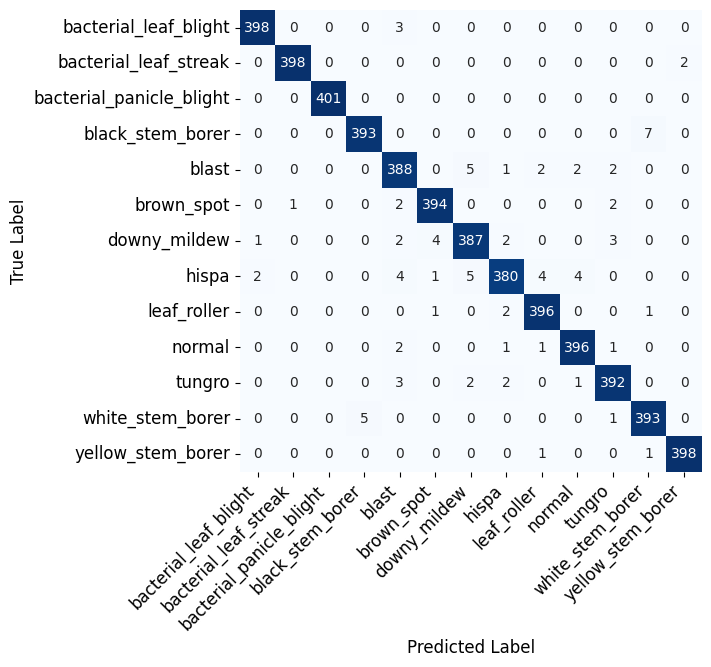

In [40]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# def plot_heatmap(y_true, y_pred, class_names, ax, title):
#     cm = confusion_matrix(y_true, y_pred)
#     sns.heatmap(
#         cm, 
#         annot=True, 
#         square=True, 
#         xticklabels=class_names, 
#         yticklabels=class_names,
#         fmt='d', 
#         cmap=plt.cm.Blues,
#         cbar=False,
#         ax=ax
#     )
#     #ax.set_title(title, fontsize=16)
#     ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45, ha="right")
#     ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
#     ax.set_ylabel('True Label', fontsize=12)
#     ax.set_xlabel('Predicted Label', fontsize=12)

# fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# class_names = dls.vocab
# plot_heatmap(test_classes, pred_classes, class_names, ax, title="Resnet34")   


# #fig.suptitle("Confusion Matrix Model Comparison", fontsize=12)
# #fig.tight_layout()
# #fig.subplots_adjust(top=1.25)
# plt.show()
# cm = confusion_matrix(test_classes, pred_classes)
# print(cm)


# -----------------------------
# Confusion Matrix Plot
# -----------------------------
def plot_heatmap(y_true, y_pred, class_names, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        square=True, 
        xticklabels=class_names, 
        yticklabels=class_names,
        fmt='d', 
        cmap=plt.cm.Blues,
        cbar=False,
        ax=ax
    )
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plot_heatmap(test_classes, pred_classes, dls.vocab, ax, title="Ensembled EfficientNet + ResNet50")
plt.show()

In [41]:
# res = pd.DataFrame({"y_true":test_classes,
#                       "y_pred":pred_classes})
# res.to_csv('result.csv', index=False)
# res


# -----------------------------
# Save Results
# -----------------------------
res = pd.DataFrame({
    "y_true": test_classes,
    "y_pred": pred_classes
})
res.to_csv('result.csv', index=False)
res

,y_true,y_pred
0,bacterial_leaf_blight,bacterial_leaf_blight
1,bacterial_leaf_blight,bacterial_leaf_blight
2,bacterial_leaf_blight,bacterial_leaf_blight
3,bacterial_leaf_blight,bacterial_leaf_blight
4,bacterial_leaf_blight,bacterial_leaf_blight
...,...,...
5195,yellow_stem_borer,yellow_stem_borer
5196,yellow_stem_borer,yellow_stem_borer
5197,yellow_stem_borer,yellow_stem_borer
5198,yellow_stem_borer,yellow_stem_borer
